# EndoScan — MRI Slice Re-Extraction from Endometrioma Masks

**Problem this fixes:** the current `mri_slice_records.json` applies one
whole-patient label to *every* slice from that patient — so a slice with no
visible pathology anywhere in it still gets labelled positive, just because
somewhere else in that patient's scan a lesion exists. That's label noise,
and it's very likely why the classifier's AUC has been stuck near chance
(~0.6–0.67) despite the class-imbalance fixes.

**What this notebook does instead:** UT-EndoMRI ships per-patient
segmentation masks for the endometrioma (`em`) structure, in the same NIfTI
space as the T2 volume. This notebook derives each slice's label directly
from whether the `em` mask has any (or enough) lesion voxels *in that
specific slice* — so "positive" means "a lesion is visible in this slice,"
not "this patient has endo somewhere."

**Output:** a new `mri_slice_records_v2.json` and a new PNG directory,
kept separate from your current data so you can compare before switching
the classifier notebook over to it.

**⚠ Important:** your existing 3,520 synthetic/augmented slices were
generated against the *old* whole-patient labels. Once slice-level labels
change here, some of those augmented copies will no longer match their
source slice's true label. Re-generate the augmented set from the new
positive slices after validating this extraction — don't mix old
augmentation with new real labels.

In [14]:
# ── Cell 1 — Imports ─────────────────────────────────────────────
# nibabel reads NIfTI (.nii / .nii.gz) volumes — the format UT-EndoMRI ships in.
# nibabel.processing (mask resampling) needs scipy.
!pip install nibabel scipy --quiet

import json
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import nibabel as nib
from nibabel.processing import resample_from_to
from PIL import Image
import matplotlib.pyplot as plt

print("Imports OK")
print(f"nibabel version: {nib.__version__}")

Imports OK
nibabel version: 5.4.2


**What this cell does:** Installs and imports `nibabel`, the library
that reads NIfTI volumes (`.nii.gz`), which is the format both the T2 scans
and the segmentation masks are stored in. Nothing else here — just setup.

In [15]:
# ── Cell 2 — Config ──────────────────────────────────────────────
# ── UPDATE THESE to match your local UT-EndoMRI download ──────────
UT_ENDOMRI_ROOT = Path.home() / 'Downloads' / 'UT-EndoMRI'
INSTITUTIONS = {
    'D1_MHS':  UT_ENDOMRI_ROOT / 'D1_MHS',
    'D2_TCPW': UT_ENDOMRI_ROOT / 'D2_TCPW',
}
# ────────────────────────────────────────────────────────────────

OUTPUT_PNG_DIR = Path('./outputs/mri_slices_v2')
OUTPUT_RECORDS = Path('./outputs/mri_slice_records_v2.json')
OUTPUT_PNG_DIR.mkdir(parents=True, exist_ok=True)

# A slice is labelled positive only if the em mask has at least this many
# lesion voxels in that slice — filters out single-voxel segmentation noise
# that wouldn't be visually identifiable as a lesion anyway. Tune this if
# your positive count looks too high or too low after a first run.
MIN_LESION_VOXELS = 5

# D1_MHS masks may have up to 3 raters (r1/r2/r3); D2_TCPW has one, unlabelled.
# Default to the first rater found, in this preference order.
D1_RATER_PREFERENCE = ['r1', 'r2', 'r3']

for name, path in INSTITUTIONS.items():
    exists = path.exists()
    print(f"{name}: {path}  {'✓ found' if exists else '✗ NOT FOUND — check the path'}")

assert all(p.exists() for p in INSTITUTIONS.values()), \
    "Fix UT_ENDOMRI_ROOT / INSTITUTIONS above before continuing."


D1_MHS: /home/joy/Downloads/UT-EndoMRI/D1_MHS  ✓ found
D2_TCPW: /home/joy/Downloads/UT-EndoMRI/D2_TCPW  ✓ found


**What this cell does:** Points to your local UT-EndoMRI download —
**update `UT_ENDOMRI_ROOT` to wherever you actually extracted the zip**
before running. Also sets `MIN_LESION_VOXELS`, a small guard against
labelling a slice positive because of one or two stray segmented voxels
that wouldn't be a visually real finding — if your resulting positive
count still looks off, this is the first thing to tune.

In [16]:
# ── Cell 2b — Diagnostic: what files actually exist on disk? ────────
# Settles two open questions before extraction: (1) do cul-de-sac (cds)
# mask files exist in this download at all, and (2) which structures/
# sequences are actually present, so the extraction script isn't guessing.
all_nii_names = []
for inst_dir in INSTITUTIONS.values():
    for patient_dir in inst_dir.iterdir():
        if patient_dir.is_dir():
            all_nii_names.extend(p.name for p in patient_dir.glob('*.nii*'))

# Extract the "structure/sequence" token from each filename, e.g.
# 'D1-000_T2.nii.gz' -> 'T2', 'D1-000_em_r1.nii.gz' -> 'em_r1'
token_counts = Counter()
for name in all_nii_names:
    m = re.match(r'^D\d-\d+_(.+?)\.nii', name)
    if m:
        token_counts[m.group(1)] += 1

print(f"Total .nii/.nii.gz files found: {len(all_nii_names)}")
print("\nFile type breakdown (structure/sequence -> count):")
for token, count in sorted(token_counts.items(), key=lambda x: -x[1]):
    print(f"  {token:<15} {count}")

cds_files = [n for n in all_nii_names if '_cds' in n]
print(f"\n'cds' files found: {len(cds_files)}")
if cds_files:
    print(f"  Sample: {cds_files[:3]}")
else:
    print("  → No cds files exist in this download at all. This is a real dataset")
    print("    limitation, not a bug in the glob pattern — POSITIVE_STRUCTURES")
    print("    should be reduced back to ['em'] only, or you'd need to request/")
    print("    check for a fuller download that includes cul-de-sac annotations.")


Total .nii/.nii.gz files found: 173

File type breakdown (structure/sequence -> count):
  T2              92
  em_r3           40
  em_r2           21
  em              11
  em_r1           9

'cds' files found: 0
  → No cds files exist in this download at all. This is a real dataset
    limitation, not a bug in the glob pattern — POSITIVE_STRUCTURES
    should be reduced back to ['em'] only, or you'd need to request/
    check for a fuller download that includes cul-de-sac annotations.


**What this cell does:** Before writing any more extraction logic on top
of an assumption, this lists every `.nii`/`.nii.gz` file actually present
across both institutions and tallies them by structure/sequence name. This
directly answers whether `cds` mask files exist in your download at all —
if the count comes back 0, that's a genuine dataset limitation (`cds`
segmentations weren't included, or weren't done, for these patients), not a
bug in the file-matching logic, and `POSITIVE_STRUCTURES` should be scaled
back to `['em']` only rather than chasing a fix that isn't there to find. If
files *do* show up here, it means the glob pattern in `find_structure_mask_file`
needs adjusting to match the real naming.

In [17]:
# ── Cell 3 — Helper functions ────────────────────────────────────

def find_patient_dirs(institution_dir: Path) -> list:
    """Each patient has their own subfolder, e.g. D1-000/, D2-006/."""
    return sorted([d for d in institution_dir.iterdir() if d.is_dir()])


def find_t2_file(patient_dir: Path) -> Path | None:
    """T2-weighted is the sequence the current pipeline already uses."""
    candidates = list(patient_dir.glob('*_T2.nii*'))
    # exclude T2FS (fat-suppressed) — a different sequence, keep to plain T2
    # to match what mri_slice_records.json already used (t2_path field)
    candidates = [c for c in candidates if 'T2FS' not in c.name]
    return candidates[0] if candidates else None


def find_structure_mask_file(patient_dir: Path, institution: str, structure: str) -> tuple[Path | None, str | None]:
    """
    Locates a segmentation mask for a given structure ('em', 'cds', etc).
    Returns (mask_path, rater_used), or (None, None) if the patient has no
    mask for that structure — a legitimate case (no finding of that type
    segmented for that patient), not a bug.
    """
    if institution == 'D1_MHS':
        for rater in D1_RATER_PREFERENCE:
            matches = list(patient_dir.glob(f'*_{structure}_{rater}.nii*'))
            if matches:
                return matches[0], rater
        return None, None
    else:  # D2_TCPW — single rater, no rater suffix in filename
        matches = list(patient_dir.glob(f'*_{structure}.nii*'))
        return (matches[0], 'single') if matches else (None, None)


def normalize_slice_to_uint8(sl: np.ndarray) -> np.ndarray:
    """
    MRI intensities aren't on a fixed 0-255 scale like a photo — normalise
    per-slice using percentile windowing so contrast is consistent across
    patients/scanners, then convert to uint8 for PNG export.
    """
    p1, p99 = np.percentile(sl, [1, 99])
    if p99 <= p1:
        return np.zeros_like(sl, dtype=np.uint8)
    sl_clipped = np.clip(sl, p1, p99)
    sl_norm = (sl_clipped - p1) / (p99 - p1) * 255.0
    return sl_norm.astype(np.uint8)


# Positive criterion: union of these structures' masks. 'em' (endometrioma)
# alone misses most non-cystic disease presentations — 'cds' (cul-de-sac
# obliteration) is a recognised MRI marker for deep infiltrating
# endometriosis and recovers that coverage. 'cy' (generic cyst) is
# deliberately excluded — ambiguous whether it includes non-endo functional
# cysts, which would reintroduce false positives.
POSITIVE_STRUCTURES = ['em', 'cds']

print("Helpers defined ✓")
print(f"Positive criterion: union of {POSITIVE_STRUCTURES} masks")

Helpers defined ✓
Positive criterion: union of ['em', 'cds'] masks


**What this cell does:** Defines the logic for locating each patient's
T2 volume and structure masks on disk, and for converting a raw MRI slice
into a proper uint8 PNG using percentile windowing. `find_structure_mask_file`
now takes a `structure` argument so it can look up any of the segmented
structures (`em`, `cds`, etc.), not just endometrioma — `POSITIVE_STRUCTURES`
defines which ones count toward a positive label. It deliberately returns
`(None, None)` for patients with no mask of that type, rather than raising
an error — that's a legitimate case, not a bug.

In [18]:
# ── Cell 4 — Main extraction loop ────────────────────────────────
records = []
patients_processed = 0
patients_missing_t2 = []
patients_with_no_positive_structures = []
structure_coverage = Counter()      # patients with a mask found for the structure at all
structure_resampled = Counter()     # of those, how many needed resampling (shape mismatch)
structure_resample_failed = Counter()  # resampling itself raised an error — genuinely unusable

for institution, inst_dir in INSTITUTIONS.items():
    is_d1 = (institution == 'D1_MHS')
    patient_dirs = find_patient_dirs(inst_dir)
    print(f"\n{institution}: {len(patient_dirs)} patient folders found")

    for patient_dir in patient_dirs:
        patient_id = patient_dir.name  # e.g. 'D1-000'

        t2_path = find_t2_file(patient_dir)
        if t2_path is None:
            patients_missing_t2.append(patient_id)
            continue

        t2_img = nib.load(str(t2_path))
        t2_data = t2_img.get_fdata()

        # Load a mask volume (resampled onto the T2 grid) for every structure
        structure_masks = {}   # structure -> (mask_data ndarray or None, rater)
        any_structure_found = False

        for structure in POSITIVE_STRUCTURES:
            mask_path, rater_used = find_structure_mask_file(patient_dir, institution, structure)
            if mask_path is None:
                structure_masks[structure] = (None, None)
                continue
            structure_coverage[structure] += 1
            any_structure_found = True

            mask_img = nib.load(str(mask_path))
            if mask_img.shape == t2_data.shape:
                mask_data = mask_img.get_fdata()
            else:
                # Shape mismatch — almost always means the mask was drawn on a
                # different sequence's grid (different resolution). Resample it
                # onto the T2 grid using the NIfTI affine transforms rather than
                # discarding it. order=0 (nearest-neighbour) keeps the mask
                # binary/integer instead of blurring label boundaries.
                structure_resampled[structure] += 1
                try:
                    resampled_img = resample_from_to(mask_img, t2_img, order=0)
                    mask_data = resampled_img.get_fdata()
                except Exception as e:
                    structure_resample_failed[structure] += 1
                    print(f"  ⚠ {patient_id}: {structure} resampling failed ({e}) — "
                          f"treating as no mask for this structure")
                    mask_data = None

            structure_masks[structure] = (mask_data, rater_used)

        if not any_structure_found:
            patients_with_no_positive_structures.append(patient_id)

        n_slices = t2_data.shape[2]
        for slice_idx in range(n_slices):
            t2_slice = t2_data[:, :, slice_idx]

            per_structure_voxels = {}
            for structure, (mask_data, rater_used) in structure_masks.items():
                if mask_data is None:
                    per_structure_voxels[structure] = 0
                else:
                    per_structure_voxels[structure] = int((mask_data[:, :, slice_idx] > 0).sum())

            label = 1 if any(v >= MIN_LESION_VOXELS for v in per_structure_voxels.values()) else 0

            png_uint8 = normalize_slice_to_uint8(t2_slice)
            fname = f"{patient_id}_sl{slice_idx:03d}_label{label}.png"
            Image.fromarray(png_uint8).save(OUTPUT_PNG_DIR / fname)

            records.append({
                'patient_id':          patient_id,
                'institution':         institution,
                'slice_idx':           slice_idx,
                'label':               label,
                'lesion_voxels':       per_structure_voxels,
                'positive_structures': [s for s, v in per_structure_voxels.items() if v >= MIN_LESION_VOXELS],
                'mask_raters':         {s: r for s, (_, r) in structure_masks.items()},
                't2_path':             str(t2_path),
                'is_d1':               is_d1,
                'filename':            fname,
            })

        patients_processed += 1

print(f"\nDone. Patients processed: {patients_processed}")
print(f"Patients missing T2 (skipped entirely): {len(patients_missing_t2)}  {patients_missing_t2[:5]}")
print(f"Patients with none of {POSITIVE_STRUCTURES} masked at all: {len(patients_with_no_positive_structures)}")
print(f"Structure mask coverage (mask file found): {dict(structure_coverage)}")
print(f"Structure masks needing resampling (shape mismatch): {dict(structure_resampled)}")
print(f"Structure masks where resampling failed: {dict(structure_resample_failed)}")
print(f"Total slices written: {len(records):,}")


D1_MHS: 50 patient folders found

D2_TCPW: 49 patient folders found

Done. Patients processed: 92
Patients missing T2 (skipped entirely): 7  ['D1-011', 'D1-014', 'D1-019', 'D1-031', 'D1-039']
Patients with none of ['em', 'cds'] masked at all: 48
Structure mask coverage (mask file found): {'em': 44}
Structure masks needing resampling (shape mismatch): {'em': 35}
Structure masks where resampling failed: {}
Total slices written: 4,242


**What this cell does:** The extraction, now with the resampling fix.
Instead of discarding a mask the moment its shape doesn't match the T2
volume, it uses `nibabel.processing.resample_from_to` to align the mask
onto the T2 grid via the NIfTI affine transforms — this is the correct
handling for masks drawn at a different resolution or on a different
sequence, as long as they share the same physical scan space, which is the
normal case for a single MRI session. `structure_resampled` tells you how
many masks needed this (compare against the shape-mismatch warnings from
your last run — this should now recover most of them instead of discarding
them), and `structure_resample_failed` flags any that genuinely couldn't be
aligned, which is a much smaller and more honest "truly unusable" count
than before.

NEW (mask-derived) label distribution
  Total slices     : 4,242
  Positive slices  : 356  (8.4%)
  Total patients   : 92
  Positive patients: 44

  Positive slices by driving structure: {('em',): 356}

Comparison against old whole-patient labels:
  Agree                          : 4,012
  Disagree (relabelled)          : 230  (5.4%)
    → old=0, new=1 (newly found) : 117
    → old=1, new=0 (was noise)   : 113
  Slices only in new extraction  : 0

  A large 'old=1, new=0' count confirms the label-noise theory —
  those were slices with no visible lesion that got a positive label
  purely from being in a positive patient's scan.


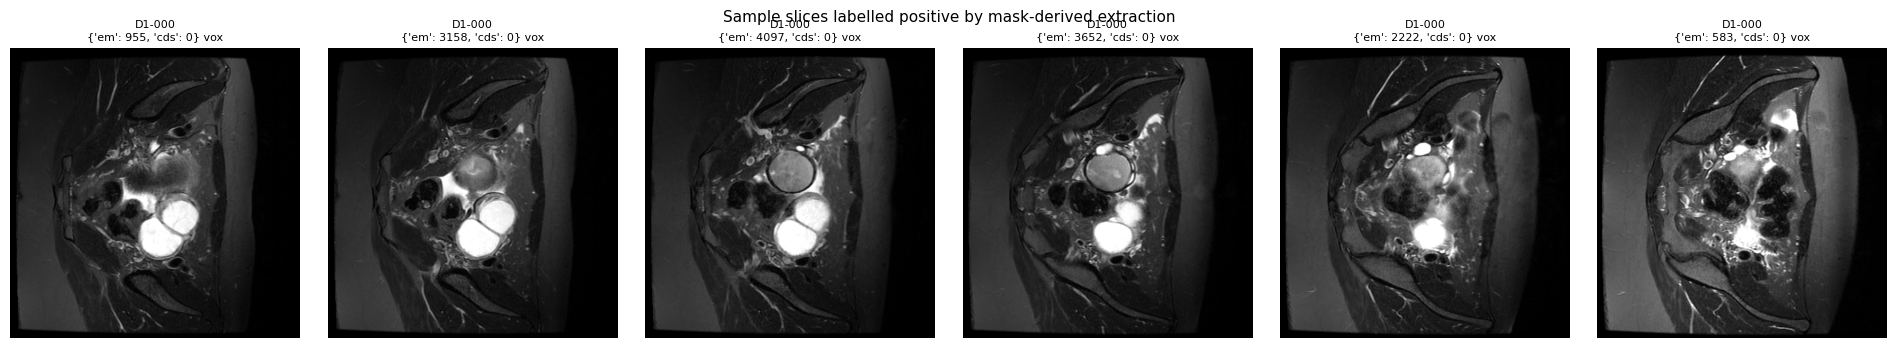

In [19]:
# ── Cell 5 — Compare new labels against the old whole-patient labels ─
n_total = len(records)
n_pos = sum(r['label']==1 for r in records)
n_patients = len(set(r['patient_id'] for r in records))
n_pos_patients = len(set(r['patient_id'] for r in records if r['label']==1))

print("NEW (mask-derived) label distribution")
print("=" * 50)
print(f"  Total slices     : {n_total:,}")
print(f"  Positive slices  : {n_pos:,}  ({n_pos/n_total*100:.1f}%)")
print(f"  Total patients   : {n_patients}")
print(f"  Positive patients: {n_pos_patients}")

# Breakdown of WHICH structure drove each positive label — useful to see
# whether 'cds' actually recovered coverage 'em' alone was missing.
struct_driver = Counter()
for r in records:
    if r['label'] == 1:
        struct_driver[tuple(sorted(r['positive_structures']))] += 1
print(f"\n  Positive slices by driving structure: {dict(struct_driver)}")

# Compare against the old records file, if available, to see how much the
# relabelling actually changed things.
OLD_RECORDS = Path('./outputs/mri_slice_records.json')
if OLD_RECORDS.exists():
    with open(OLD_RECORDS) as f:
        old_records = json.load(f)
    old_lookup = {(r['patient_id'], r['slice_idx']): r['label'] for r in old_records}

    agree = disagree = only_new = 0
    flips_to_positive = flips_to_negative = 0
    for r in records:
        key = (r['patient_id'], r['slice_idx'])
        if key not in old_lookup:
            only_new += 1
            continue
        old_label = old_lookup[key]
        if old_label == r['label']:
            agree += 1
        else:
            disagree += 1
            if r['label'] == 1:
                flips_to_positive += 1
            else:
                flips_to_negative += 1

    print(f"\nComparison against old whole-patient labels:")
    print(f"  Agree                          : {agree:,}")
    print(f"  Disagree (relabelled)          : {disagree:,}  ({disagree/(agree+disagree)*100:.1f}%)")
    print(f"    → old=0, new=1 (newly found) : {flips_to_positive:,}")
    print(f"    → old=1, new=0 (was noise)   : {flips_to_negative:,}")
    print(f"  Slices only in new extraction  : {only_new:,}")
    print(f"\n  A large 'old=1, new=0' count confirms the label-noise theory —")
    print(f"  those were slices with no visible lesion that got a positive label")
    print(f"  purely from being in a positive patient's scan.")
else:
    print(f"\nNo old records file found at {OLD_RECORDS} to compare against.")

# ── Sample positive slices — sanity check the masks actually align ──
pos_samples = [r for r in records if r['label']==1][:6]
if pos_samples:
    fig, axes = plt.subplots(1, len(pos_samples), figsize=(3.2*len(pos_samples), 3.5))
    if len(pos_samples) == 1:
        axes = [axes]
    for ax, rec in zip(axes, pos_samples):
        img = Image.open(OUTPUT_PNG_DIR / rec['filename'])
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{rec['patient_id']}\n{rec['lesion_voxels']} vox", fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample slices labelled positive by mask-derived extraction', fontsize=11)
    plt.tight_layout()
    plt.show()

**What this cell does:** This is the validation step — don't skip it.
It compares the new mask-derived labels against your existing
`mri_slice_records.json` slice-by-slice, so you can see exactly how many
slices flipped label and in which direction. A large `old=1, new=0` count
is direct confirmation of the label-noise theory: those are slices that
were called positive only because they belonged to a positive patient, not
because anything was visible in them — that's very likely where a large
share of the weak AUC came from. It also renders a handful of
newly-positive sample slices with their lesion voxel counts so you can
visually sanity-check that the masks are actually aligning with plausible
anatomy before trusting this extraction over the old one.

In [20]:
# ── Cell 6 — Save the new records file ───────────────────────────
with open(OUTPUT_RECORDS, 'w') as f:
    json.dump(records, f, indent=2)

print(f"Saved {len(records):,} records → {OUTPUT_RECORDS}")
print(f"Saved {len(records):,} PNGs     → {OUTPUT_PNG_DIR}")
print()
print("Next steps:")
print("  1. Review the comparison and sample slices above before trusting this.")
print("  2. If it looks right, point the classifier notebook's REAL_RECORDS")
print("     and REAL_PNG_DIR at these v2 paths instead of the originals.")
print("  3. Re-generate the augmented/synthetic set from the NEW positive")
print("     slices — the old augmented set was built against old labels and")
print("     will now be partially mismatched.")
print("  4. Re-run Phase 2 onward in the classifier notebook with the new data.")

Saved 4,242 records → outputs/mri_slice_records_v2.json
Saved 4,242 PNGs     → outputs/mri_slices_v2

Next steps:
  1. Review the comparison and sample slices above before trusting this.
  2. If it looks right, point the classifier notebook's REAL_RECORDS
     and REAL_PNG_DIR at these v2 paths instead of the originals.
  3. Re-generate the augmented/synthetic set from the NEW positive
     slices — the old augmented set was built against old labels and
     will now be partially mismatched.
  4. Re-run Phase 2 onward in the classifier notebook with the new data.
